In [1]:
# %% Import most relevant packages and definitions
import DBW.udkm1Dsim as ud

import matplotlib.pyplot as plt
import numpy as np
import lmfit as lm

%matplotlib inline

In [2]:
u = ud.u  # import the pint unit registry from udkm1Dsim
u.setup_matplotlib()  # use matplotlib with pint units

u.ang = 1e-10 *u.m
u.gm = 1e-3 * u.kg

forceRecalc = False
cache_dir='cache'

In [3]:
# %% Set simulation parameters
T_start = 450
heatDiffusion = True
only_heat_var = True

F = 25

In [4]:
# %% Introduce necessary elements from database
Mg = ud.Atom('Mg')
O  = ud.Atom('O')
Pt = ud.Atom('Pt')

In [5]:
# %% Platinum
prop_Pt = {}
#prop_Pt['heat_capacity'] = ['lambda T: 740/21450*T',
#                            133 * u.J/(u.kg*u.K)]
prop_Pt['heat_capacity'] = ['lambda T: 740/21450*T',
                            'lambda T: (23.8992 +7.89939e-3*T -3.77463e-6*T**2 +1.53451e-9*T**3 -27697.5/(T**2))/(195.084/1000.0)']
prop_Pt['therm_cond'] = ['lambda T: (71-5)*(T[0]/T[1])',
                         5 * u.W/(u.m * u.K)]
prop_Pt['sub_system_coupling'] = ['lambda T: -0.5* (-7.09e-3*T[0]**5 +3.64e2*T[0]**4  -7.30e6*T[0]**3   +7.29e10*T[0]**2 -3.85e14*T[0] + 12.046e17)*(T[0]-T[1])',
                                  'lambda T:  0.5* (-7.09e-3*T[0]**5 +3.64e2*T[0]**4  -7.30e6*T[0]**3   +7.29e10*T[0]**2 -3.85e14*T[0] + 12.046e17)*(T[0]-T[1])'] 
prop_Pt['lin_therm_exp'] = ['lambda T: 2.22e-9*T',
                            'lambda T: (1.300e-13*T**5 + -4.176e-10*T**4 + 5.179e-07*T**3 + -3.088e-04*T**2 + 9.093e-02*T + 9.343e+00)*1e-6 - 2.22e-9*T']
prop_Pt['sound_vel'] = 4.242 *u.nm/u.ps
prop_Pt['opt_ref_index'] = 0.84426 + 10.641j #1030nm

c_Pt = 0.220 * u.nm
# calculate so that density of unit cell is the density of Pt -> the simulation uses the mass per unit cell.
prop_Pt['a_axis'] = 0.066666667*u.nm
prop_Pt['b_axis'] = 1*u.nm

prop_Pt['deb_wal_fac'] = ['0','sqrt(1*( (0.02938 + 0.1090e-2*T + 0.4310e-6*(T**2) - 0.4681e-9*(T++3) + 0.1829e-12*(T**4)))/(8*pi**2))*1E-10'] #peng gao

layer_Pt = ud.UnitCell('Pt', 'Platinum', c_Pt, **prop_Pt)
layer_Pt.add_atom(Pt, 0)

Number of subsystems changed from 1 to 2.


In [6]:
# %% MgO interface layer
prop_MgO_int = {}
prop_MgO_int['heat_capacity'] = [0.00001,877]
#prop_MgO_int['therm_cond'] = [0, 50/3/250]
prop_MgO_int['therm_cond'] = [0,'lambda T: 2.42e4 * (T**-1.114) /1.25 / 250'] #from [J. Res. Natl. Inst. Stand. Technol. 103, 357 (1998)
prop_MgO_int['sub_system_coupling'] = [1, 1]
prop_MgO_int['lin_therm_exp'] = [0,
                                 'lambda T: 1.61*(1.664e-13*T**5 + -5.689e-10*T**4 + 7.591e-07*T**3 + -4.935e-04*T**2 + 1.633e-01*T + -1.033e+01)*1e-6']
prop_MgO_int['sound_vel'] = 9.12  *u.nm/u.ps
prop_MgO_int['opt_ref_index'] = 1.728
prop_MgO_int['deb_wal_fac'] = ['0','0']

cMgO           = 0.421272 * u.nm
# calculate so that density of unit cell is the density of MgO -> the simulation uses the mass per unit cell.
prop_MgO_int['a_axis'] = 0.08874*u.nm
prop_MgO_int['b_axis'] = 1*u.nm

layer_MgO_int = ud.UnitCell('MgOint', 'MgOint', cMgO, **prop_MgO_int)
layer_MgO_int.add_atom(Mg, 0)
layer_MgO_int.add_atom(O, 0)
layer_MgO_int.add_atom(Mg, 0)
layer_MgO_int.add_atom(O, 0)# %% MgO layer

Number of subsystems changed from 1 to 2.


In [7]:
# %% MgO layer
prop_MgO = {}
prop_MgO['heat_capacity'] = [0.00001, 877]
#prop_MgO['therm_cond'] = [0, 50/3] 
prop_MgO['therm_cond'] = [0,'lambda T: 2.42e4 * (T**-1.114) /1.25'] #from [J. Res. Natl. Inst. Stand. Technol. 103, 357 (1998)
prop_MgO['sub_system_coupling'] = [1, 1]
prop_MgO['lin_therm_exp'] = [0,
                             'lambda T: 1.61*(1.664e-13*T**5 + -5.689e-10*T**4 + 7.591e-07*T**3 + -4.935e-04*T**2 + 1.633e-01*T + -1.033e+01)*1e-6']
prop_MgO['sound_vel'] = 9.12  *u.nm/u.ps
prop_MgO['opt_ref_index'] = 1.7222
prop_MgO['deb_wal_fac'] = ['0','0']

cMgO           = 0.421272 * u.nm
# calculate so that density of unit cell is the density of MgO -> the simulation uses the mass per unit cell.
prop_MgO['a_axis'] = 0.08874*u.nm
prop_MgO['b_axis'] = 1*u.nm

layer_MgO = ud.UnitCell('MgO', 'MgO', cMgO, **prop_MgO)
layer_MgO.add_atom(Mg, 0)
layer_MgO.add_atom(O, 0)
layer_MgO.add_atom(Mg, 0)
layer_MgO.add_atom(O, 0)# %% MgO layer

Number of subsystems changed from 1 to 2.


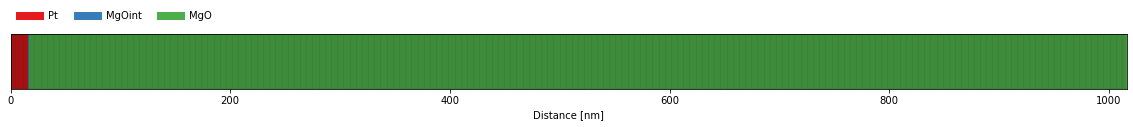

Structure properties:

Name   : 16nm Pt
Thickness : 1016.36 nanometer
Roughness : 0.00 nanometer
----
72 times Platinum: 15.84 nanometer
1 times MgOint: 0.42 nanometer
2374 times MgO: 1000.10 nanometer
----
no substrate



In [8]:
# %% Build Sample structure
S = ud.Structure('16nm Pt')

S.add_sub_structure(layer_Pt, np.int_(np.round(15.9*u.nm/c_Pt)))
S.add_sub_structure(layer_MgO_int, np.int_(1))
S.add_sub_structure(layer_MgO, np.int_(np.round(1000*u.nm/cMgO))) #only heat
#S.add_sub_structure(layer_MgO, np.int_(np.round(8000*u.nm/cMgO))) #with accoustic for 1600ps
S.visualize()
print(S)

In [9]:
# %% Define the simulation grid in time and space
# Part 1: Linear spacing from -250 to -5 in steps of 5
part1 = np.arange(-250, -10, 10)

# Part 2: Linear spacing from -5 to -1 in steps of 1
part2 = np.arange(-10, -1, 3)

# Part 3: Linear spacing from -1 to 5 in steps of 0.25
part3 = np.arange(-1, 5, 0.25)  # include 10

# Part 4: Exponential spacing from 10 to 1600
num_points = 110  # adjust for resolution
part4 = np.logspace(np.log10(5), np.log10(2700), num=num_points)

# Concatenate all parts
delay_axis = np.concatenate([part1, part2, part3, part4])

#print(delay_axis)
print("Total points:", len(delay_axis))

# %% Define the simulation grid in time and space
delays = delay_axis*u.ps
_, _, distances = S.get_distances_of_layers()

Total points: 161


In [10]:
# %% Initialize the heat simulation and set excitation conditions
H = ud.Heat(S, forceRecalc, cache_dir=cache_dir) #S, force recalc
H.excitation = {'fluence':     [F]*u.mJ/u.cm**2,
                'delay_pump':  [0.]*u.ps,
                'pulse_width': [600]*u.fs,
                'multilayer_absorption': True,
                'wavelength': 1030*u.nm,
                'theta': (55+2)*u.deg}

In [11]:
H.save_data = True
H.disp_messages = True

# enable heat diffusion
H.heat_diffusion = heatDiffusion

# set the boundary conditions
H.boundary_conditions = {'top_type': 'isolator', 'bottom_type': 'isolator'}

# The resulting temperature profile is calculated in one line:
init_temp = np.zeros([S.get_number_of_layers(), 2])
init_temp[:, 0] = T_start * np.ones(S.get_number_of_layers())

Absorption profile is calculated by multilayer formalism.
Total reflectivity of 89.7 % and transmission of 4.3 %.


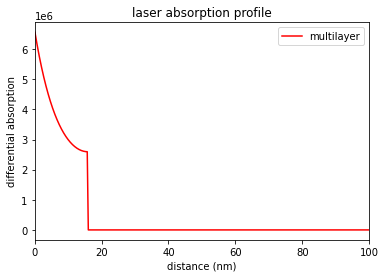

In [12]:
# %% Model initial Excitation profile
plt.figure()
dAdz, _, _, _ = H.get_multilayers_absorption_profile()
plt.plot(distances.to('nm'), dAdz, '-r', label='multilayer')
plt.legend()
plt.xlabel('distance (nm)')
plt.ylabel('differential absorption')
plt.title('laser absorption profile')
plt.xlim([0, 100])

plt.show()

In [13]:
# %% Actual Heat simulation takes place here
temp_map, delta_temp = H.get_temp_map(delays, T_start)

_temp_map_ loaded from file:
	temp_map_121f202e5380ad72a3ef7c768ac7a275_7cd9dddcfecf3040af933d8ce36b422f.npz


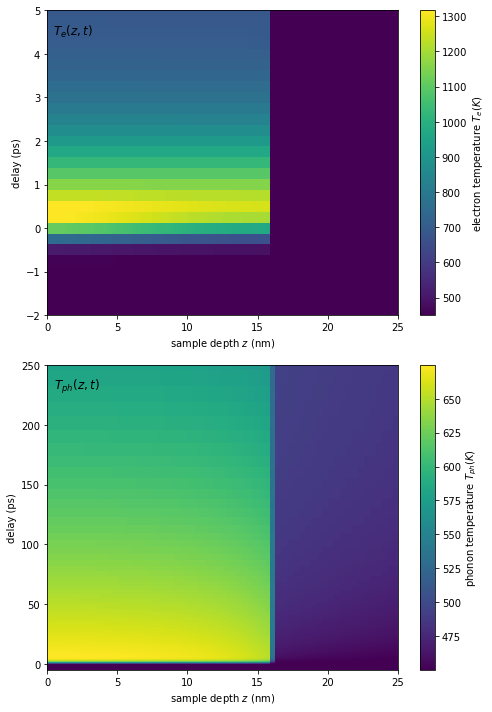

In [14]:
plt.figure(figsize=[7, 10])
plt.subplot(2, 1, 1)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map[:, :, 0])
cbar = plt.colorbar()
cbar.set_label('electron temperature $T_{e} (K)$')
plt.ylim([-2, 5])
plt.xlim([0, 25])
plt.xlabel('sample depth $z$ (nm)')
plt.ylabel('delay (ps)')
plt.title('$T_{e}(z,t)$', y=0.9, x=0.075)

plt.subplot(2, 1, 2)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map[:, :, 1]+0.001)
cbar = plt.colorbar()
cbar.set_label('phonon temperature $T_{ph} (K)$')
plt.ylim([-5, 250])
plt.xlim([0, 25])
plt.xlabel('sample depth $z$ (nm)')
plt.ylabel('delay (ps)')
plt.title('$T_{ph}(z,t)$', y=0.9, x=0.085)

plt.tight_layout()

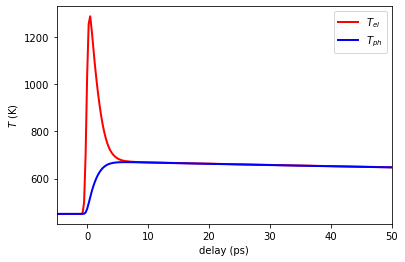

In [15]:
select_Pt= S.get_all_positions_per_unique_layer()['Pt']
T_el_Au = np.mean(temp_map[:, select_Pt, 0], 1)
T_ph_Au = np.mean(temp_map[:, select_Pt, 1], 1)

plt.figure()
plt.plot(delays.to('ps').magnitude, T_el_Au, color="red", label="$T_{el}$", lw=2)
plt.plot(delays.to('ps').magnitude, T_ph_Au, color="blue", label="$T_{ph}$", lw=2)
plt.xlim([-5,50])
plt.xlabel('delay (ps)')
plt.ylabel(r'$T$ (K)')
plt.legend();

In [16]:
# %% Strain calculation using phonon numerics class
Pnum = ud.PhononNum(S, forceRecalc, only_heat=only_heat_var, cache_dir=cache_dir)
Pnum.save_data = True
Pnum.disp_messages = True

strain_map = Pnum.get_strain_map(delays, temp_map, delta_temp)

_strain_map_ loaded from file:
	strain_map_num_5f64d91a6e5e9cea110b5375b98c0e4f_09dde9ce6e7aba7d41941b244b80e23b.npz


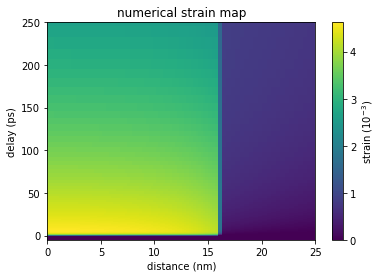

In [17]:
# %% Plot Strain Map  and layer averaged strains

plt.figure()
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude,1E3*strain_map, shading='auto')
cbar = plt.colorbar()
cbar.set_label('strain ($10^{-3}$)')
plt.ylim([-5, 250])
plt.xlim([0, 25])
plt.xlabel('distance (nm)')
plt.ylabel('delay (ps)')
plt.title('numerical strain map')
plt.show()

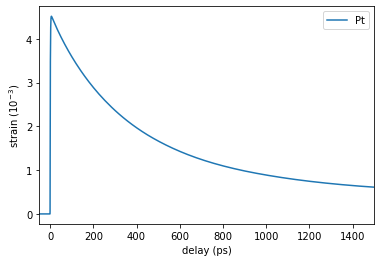

In [18]:
plt.figure()
plt.plot(delays.to('ps').magnitude, 1e3*np.mean(strain_map[:, select_Pt], 1), label="Pt")
plt.ylabel('strain ($10^{-3}$)')
plt.xlabel('delay (ps)')
plt.xlim([-50, 1500])
plt.legend()
plt.show()

In [19]:
# %% x-ray scattering
dyn = ud.XrayDynDebyeWaller(S, forceRecalc)
dyn.disp_messages = True
dyn.save_data = False

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized


In [20]:
order=4

Calculating _homogenous_reflectivity_ ...
Elapsed time for _homogenous_reflectivity_: 0.024871 s


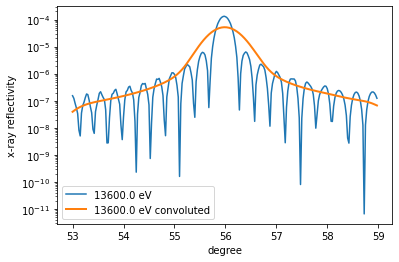

In [21]:
# %% Homogeneous X-ray scattering
dyn.energy = np.r_[6800/2*order]*u.eV  # set photon energie

dyn.theta = 1*np.r_[53:59:0.025]*u.degree  # set theta range

R_hom, A = dyn.homogeneous_reflectivity()

#instrument function / mosaicity of sample
FWHM = order * 0.02/1e-10  # Angstrom
sigma = FWHM/2.3548

def handle(x): return np.exp(-((x)/sigma)**2/2)
y_conv = dyn.conv_with_function(R_hom[0, :], dyn._qz[0, :], handle)

plt.figure()
plt.semilogy(dyn.theta[0, :]/1, R_hom[0, :], label='{}'.format(dyn.energy[0]))
plt.semilogy(dyn.theta[0, :], y_conv, label='{} convoluted'.format(dyn.energy[0]), lw=2)
plt.ylabel('x-ray reflectivity')
#plt.xlabel(r'$q_z$ ($\mathrm{\AA}^{-1}$)')
plt.legend()
plt.show()


In [23]:
# %% Inhomogeneous X-ray scattering
parallel = True

if parallel:
    from dask.distributed import Client
    client = Client()
    R_seq = dyn.inhomogeneous_reflectivity(strain_map, temp_map, calc_type='parallel', dask_client=client)
    client.close()
else:
    R_seq = dyn.inhomogeneous_reflectivity(strain_map, temp_map, calc_type='sequential')

R_seq_conv = np.zeros_like(R_seq)
for i, delay in enumerate(delays):
    R_seq_conv[i, 0, :] = dyn.conv_with_function(
        R_seq[i, 0, :], dyn._qz[0, :], handle)

Calculating _inhomogeneousReflectivity_ ...


2025-11-11 09:18:26,006 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/gpfs/exfel/sw/software/mambaforge/22.11/envs/202301/lib/python3.9/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nbytes = await stream.read_bytes(fmt_size)
asyncio.exceptions.CancelledError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/gpfs/exfel/sw/software/mambaforge/22.11/envs/202301/lib/python3.9/asyncio/tasks.py", line 490, in wait_for
    return fut.result()
asyncio.exceptions.CancelledError

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/gpfs/exfel/sw/software/mambaforge/22.11/envs/202301/lib/python3.9/site-packages/distributed/comm/core.py", line 373, in connect
    handshake = await wait_for(comm.read(), time_left())
  File "/gpfs/exfel/sw/software/mambaforge/22.11/envs/2

Elapsed time for _inhomogeneous_reflectivity_: 295.103696 s


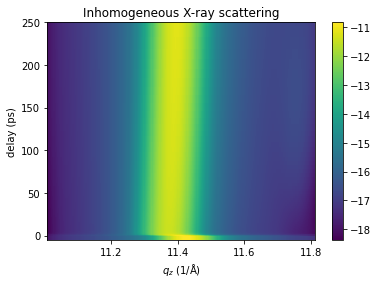

In [24]:
# %% Plot Strain Map  and layer averaged strains
plt.figure()
plt.pcolormesh(dyn._qz[0, :]*1E-10, delays.to('ps').magnitude, np.log(R_seq_conv[:, 0, :]))
plt.colorbar()
plt.ylim([-5, 250])
plt.xlabel('$q_z$ (1/Å)')
plt.ylabel('delay (ps)')
plt.title('Inhomogeneous X-ray scattering')
plt.show()

In [25]:
# %% fiting of simulation data:
from tqdm import tqdm

plotFitResult = False  # plot each and every fit?
plotDiffResult = False    # plot each differenz pumped - unpumped
WIDTHRATIOS = [10, 1]  # Ratio of subplots before and after tsplit

qz = dyn.qz[0, :]/10*u.nm
selectt0 = (delays/u.ps <= -0.5) & (delays/u.ps > -2)

# 1.2 Initializing the result vectors
latticeConstantFit = np.zeros(len(delays))
centerFit  = np.zeros(len(delays))
widthFit   = np.zeros(len(delays))
areaFit    = np.zeros(len(delays))

# Iterating through all Rockingcurves for each delay fitting each peak by a model and export the fit parameters
# Initializes the fit model
model = lm.models.PseudoVoigtModel(prefix="g1_")+lm.models.LinearModel() 
pars = lm.Parameters()
# Name               startValue 	 	     	                    Vary     	Min       Max
pars.add_many(('g1_center',       order*2.86,      True, order*2.5, order*2.95),
              ('g1_sigma',        0.02,     True),
              ('g1_amplitude',    0.00012,  True),
              ('g1_fraction',     0.2,      True, 0, 1),
              ('intercept',       0,        True),
              ('slope',           0,        True),
             )


Intensities = np.mean(R_seq_conv[delays < 0, 0, :], 0)
resultFitRef = model.fit(Intensities, pars, x=qz)

pars.add_many(('g1_center',       resultFitRef.values["g1_center"],      True,     order*2.5,    order*2.95),
              ('g1_sigma',        resultFitRef.values["g1_sigma"],       True),
              ('g1_amplitude',    resultFitRef.values["g1_amplitude"],   True),
              ('g1_fraction',     resultFitRef.values["g1_fraction"],    False),
              ('intercept',       0,        True),
              ('slope',           0,        True),
             )

resultFit = []

for i in tqdm(range(len(delays))):
    # Start Iterating
    t = delays[i]
    Intensities   = R_seq_conv[i, 0, :]
    resultFit.append(model.fit(Intensities, pars, x=qz))
    centerFit[i]  = resultFit[i].values["g1_center"]
    widthFit[i]   = resultFit[i].values["g1_sigma"]
    areaFit[i]    = resultFit[i].values["g1_amplitude"]

100%|██████████| 161/161 [00:04<00:00, 33.35it/s]


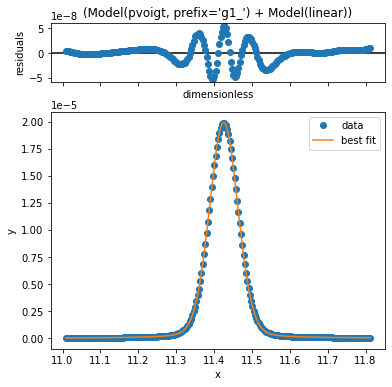

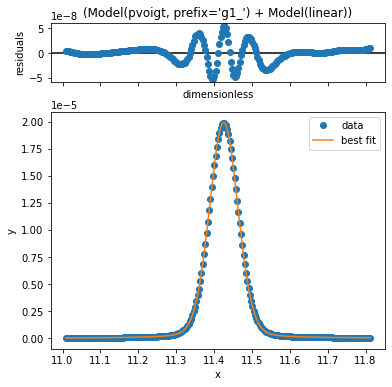

In [26]:
resultFitRef.plot()

2.25 <Unit('picosecond')>

<Figure size 432x288 with 0 Axes>

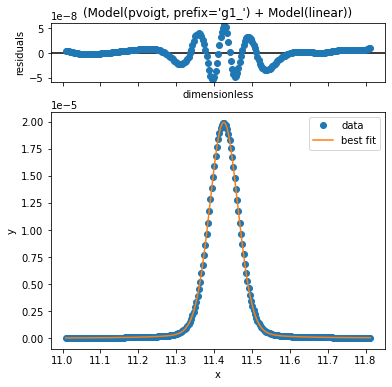

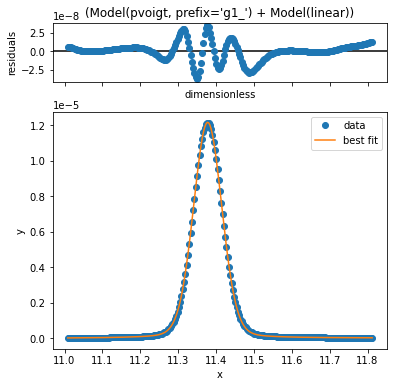

In [27]:
plt.figure()
resultFit[10].plot()
i=40
resultFit[i].plot()
delays[i]

In [28]:
# %%1.3 Calculating the relative changes of the fit parameters
def rel_change(data_array, fixpoint):
    rel_change_array = (data_array-fixpoint)/fixpoint
    return(rel_change_array)

latticeConstantFit = 2*np.pi/centerFit
strainFit = rel_change(latticeConstantFit, np.mean(latticeConstantFit[selectt0]))
widthFitrelative = rel_change(widthFit, np.mean(widthFit[selectt0]))
areaFitrelative = rel_change(areaFit, np.mean(areaFit[selectt0]))

In [29]:
def conv_with_function_nonuniform(signal, time, kernel_func):
    """
    Convolve signal(time) with kernel_func, works for non-uniform spacing.
    Kernel is normalized at each evaluation point.
    """
    n = len(time)
    out = np.zeros_like(signal, dtype=float)

    for i in range(n):
        kernel = kernel_func(time - time[i])
        # normalize kernel so its area = 1
        norm = np.trapz(kernel, time)
        if norm != 0:
            kernel /= norm
        out[i] = np.trapz(signal * kernel, time)
    
    return out

# --- Your Gaussian kernel ---
FWHM = 60.0  # ps
sigma = FWHM / 2.3548

def handle(x):
    return np.exp(-0.5 * (x/sigma)**2)

# --- Run convolutions ---
time = delays.to('ps').magnitude

strainFitConv = conv_with_function_nonuniform(strainFit, time, handle)
widthFitrelativeConv = conv_with_function_nonuniform(widthFitrelative, time, handle)
areaFitrelativeConv = conv_with_function_nonuniform(areaFitrelative, time, handle)

TempPt = np.mean(temp_map[:, select_Pt, 1], 1)
TempPtConv = conv_with_function_nonuniform(np.mean(temp_map[:, select_Pt, 1], 1), time, handle)

In [30]:
# Load numeric table (skips header row if present)
import pandas as pd

# Load the tab-separated file
df = pd.read_csv("export_222.txt", sep="\t")

# Convert each column into a numpy array
delay = df["delay"].values
strain = df["strain"].values
amplitude = df["amplitude"].values
namplitude = df["namplitude"].values
width = df["width"].values

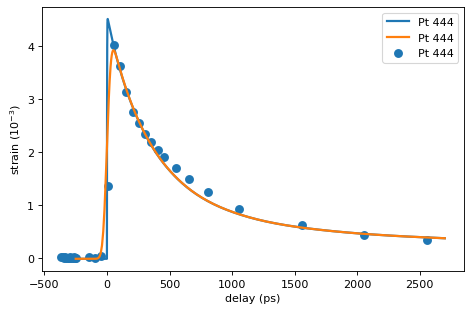

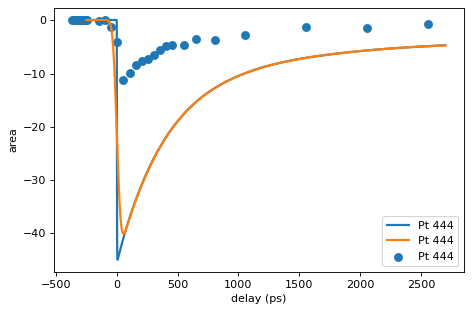

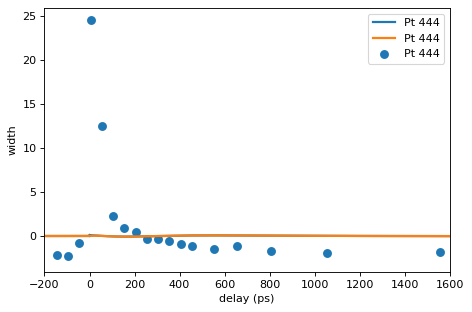

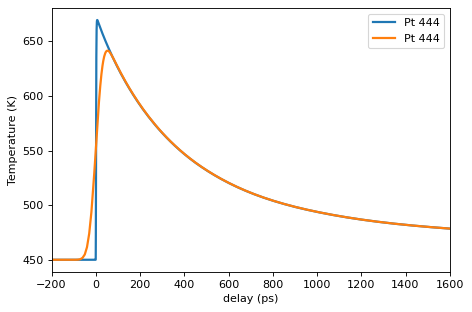

In [31]:
# %% Plot Strain Map  and layer averaged strains
offset = -55

delay = df["delay"].values-offset


peak = str(int(111*order))
plt.figure(linewidth=2, dpi=80)

plt.plot(delays.to('ps').magnitude, strainFit*1000, label='Pt '+ peak, lw=2)
plt.plot(delays.to('ps').magnitude, strainFitConv*1000, label='Pt '+ peak, lw=2)

plt.scatter(delay, strain, label='Pt '+ peak, lw=2)

plt.xlabel('delay (ps)')
plt.ylabel(r'strain $\left(10^{-3}\right)$')
plt.legend()

#plt.xlim([-200,1600])

plt.tight_layout()


plt.figure(linewidth=2, dpi=80)
plt.plot(delays.to('ps').magnitude, areaFitrelative*100, label='Pt '+ peak, lw=2)
plt.plot(delays.to('ps').magnitude, areaFitrelativeConv*100, label='Pt '+ peak, lw=2)

plt.scatter(delay, namplitude-100, label='Pt '+ peak, lw=2)

plt.xlabel('delay (ps)')
plt.ylabel(r'area')
plt.legend()

#plt.xlim([-200,1600])

plt.tight_layout()


plt.figure(linewidth=2, dpi=80)
plt.plot(delays.to('ps').magnitude, widthFitrelative*100, label='Pt '+ peak, lw=2)
plt.plot(delays.to('ps').magnitude, widthFitrelativeConv*100, label='Pt '+ peak, lw=2)

plt.scatter(delay, width-100, label='Pt '+ peak, lw=2)

plt.xlabel('delay (ps)')
plt.ylabel(r'width')
plt.legend()

plt.xlim([-200,1600])

plt.tight_layout()


plt.figure(linewidth=2, dpi=80)
plt.plot(delays.to('ps').magnitude, TempPt, label='Pt '+ peak, lw=2)
plt.plot(delays.to('ps').magnitude, TempPtConv, label='Pt '+ peak, lw=2)

plt.xlabel('delay (ps)')
plt.ylabel(r'Temperature (K)')
plt.legend()

plt.xlim([-200,1600])

plt.tight_layout()

In [32]:
#export simulation for tex plotting:
dataSim = np.vstack((
    delays.to('ps').magnitude,
    strainFit *1000,
    strainFitConv *1000,
    areaFitrelative *100,
    areaFitrelativeConv *100,
    widthFitrelative *100,
    widthFitrelativeConv *100,
    TempPt,
    TempPtConv,
))

np.savetxt('sim_2_F=' +str(F) + '_' + str(order*111) +'.txt',np.transpose(dataSim[:,:]))

In [33]:
5

5

## 

In [ ]:
3